<a href="https://colab.research.google.com/github/DevanMayer/EE-480-Assignments/blob/main/EE_480_Project_6_Final_Report_(Devan_Mayer%2C_Shomrick_Bhadra%2C_Daniel_Lira).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Report**

**Background Information:**


Smart charging such as time-shifting and managed charging significantly reduces evening peaks and can avoid many distribution level overloads and other voltage problems. This can be done without any major infrastructure upgrades. NREL shows how to apply smart-charging strategies that spread charging energy across off-peak hours which reduces transformer and feeder peak loading.


Feeders and Transformers hosting capacity is limited in lots of real feeders. However, there are uncontrolled clustered EV charging that can create transformer overloads and voltage sags which require control strategies or upgrades. Hosting capacities studies indicate that many feeders will need upgrades under high-adoption scenarios unless the control and operational measures are used.


Tooling and high-resolution time-series modeling are very important. NREL-developed tools such as  EVI-DiST and time-series analyses help identify local bottlenecks that static snapshots miss. Feeder-level and high-resolution models reveal secondary/household interactions and local voltage violations.

     
 Customer response to pricing and managed charging programs can materially change outcomes behavioral participation and program design are key uncertainties. NREL studies indicate that the time-of-use and price signals can shift charging behavior. However, the impact depends strongly on participation and charger/vehicle quality.
Vehicle-grid integration offers additional mitigation options but includes requirements that must be planned for. DOE and NREL highlight the VGI Benefits for postponing upgrades with non-trivial implementation barriers.




# **24 Hour Quasi-Static Time-series Power Flow Analysis**
***`Background and Motivation:`***
The rapid adoption of Electric Vehicles (EVs) in residential neighborhoods introduces new challenges for distribution system operation. As EV owners tend to charge vehicles during evening hours when household demand is already high, simultaneous charging can cause:

Voltage violations (bus voltages dropping below acceptable limits)

Thermal overloading of distribution transformers and feeder lines

Increased system losses and reduced equipment life

The utility seeks to evaluate how the existing distribution feeder (modeled using a modified IEEE 14-bus test system representing a typical residential area) will perform under varying EV charging scenarios.

A time-series (quasi-static) power flow analysis over a 24-hour period will capture the temporal variations of load and EV charging behavior, enabling data-driven decisions on infrastructure upgrades or control strategies.

***`Objectives:`***

The main objective of this study is to perform a 24-hour quasi-static time-series power flow analysis of a residential feeder with high EV penetration to assess system performance and propose mitigation strategies if operational problems are detected.

Specific objectives include:

-Develop a 24-hour load and EV charging profile for each bus in the modified IEEE 14-bus system.

-Perform quasi-static time-series power flow simulations to evaluate voltage levels, line loading, transformer loading, and power losses.

-Identify time intervals and locations of voltage violations or equipment overloads.

-Propose and evaluate mitigation measures such as:

-Smart charging coordination

-Transformer or conductor upgrades

-On-load tap changer (OLTC) control or reactive power support (e.g., PV inverters)

-Summarize findings and provide actionable recommendations for the utility’s planning and operation teams.

In this study we made use of algorithms learned in class lecture notes for power flow analysis, and the calculation of various variables that involved in power flow analysis, arrays, vectors, and dictionaries for storage of values, for loops to enable looping through the different hours of the day,key-value mapping for accesssig more tedious values in the IEEE case14.m file, and plotting functions to display and graph our results in this study.

In [ ]:
#Deliverable 3 Code:

import Pkg
using Pkg
Pkg.add(["PowerModels", "JSON"])
Pkg.add("Ipopt")
#Pkg.add("IJulia")
Pkg.add("Plots")
Pkg.add("PowerModels")
Pkg.add("Plots")
Pkg.add("Statistics")
Pkg.add("LaTeXStrings")


    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Distances ──────────────── v0.10.12
   Installed NLsolve ────────────────── v4.5.1
   Installed FiniteDiff ─────────────── v2.29.0
   Installed JSON ───────────────────── v0.21.4
   Installed Memento ────────────────── v1.4.1
   Installed BenchmarkTools ─────────── v1.6.3
   Installed MutableArithmetics ─────── v1.6.7
   Installed CodecBzip2 ─────────────── v0.8.5
   Installed NLSolversBase ──────────── v7.10.0
   Installed StructTypes ────────────── v1.11.0
   Installed JSON3 ──────────────────── v1.14.3
   Installed InfrastructureModels ───── v0.7.8
   Installed LineSearches ───────────── v7.5.1
   Installed PowerModels ────────────── v0.21.5
   Installed MathOptInterface ───────── v1.48.0
   Installed DifferentiationInterface ─ v0.7.12
   Installed JuMP ───────────────────── v1.29.3
    Updating `~/.julia/environments/v1.11/Project.toml`
⌅ [682c06a0] + JSON v0.21.4
  [c36e90e8] 

In [3]:
using PowerModels
using JSON
using Printf
using Ipopt
using Plots
# ---------------------------------------------------------------------------
# 1. Load the MATPOWER case file (ensure case14.m is in the same directory)
# ---------------------------------------------------------------------------
#####NOTES FROM CLASS: what if you don't get paid to use battery but paid to have the battery, a fleet of batteries if you will
#///////////////////////////////////////////////
# Loading Case File
case_file_path = joinpath(dirname(pathof(PowerModels)), "..", "test/data/matpower/case14.m")
case_data = PowerModels.parse_file(case_file_path)

#This is the copied data file that we are manipulating and working with
case_residential_neigborhood = deepcopy(case_data)


println("✅ Successfully loaded ", case_file_path)
println("Number of buses: ", length(case_residential_neigborhood["bus"]))
println("Number of generators: ", length(case_residential_neigborhood["gen"]))
println("Number of branches: ", length(case_residential_neigborhood["branch"]))

LoadError: ArgumentError: Package PowerModels not found in current path.
- Run `import Pkg; Pkg.add("PowerModels")` to install the PowerModels package.

In [ ]:
case_residential_neigborhood["branch"]["9"]

# --- Run the Power Flow on the Neighborhood case ---
result = solve_ac_pf(case_residential_neigborhood, Ipopt.Optimizer)
# --- Print a System Report for the Neighborhood Case ---
println("\n--- Residential Neihborhood Case System Report ---")

# 1. Check Bus Voltages
println("\n--- Bus Voltages ---")
println("Bus | Voltage (p.u.) | Angle (deg)")
println("------------------------------------")


# First, build a reference model to easily access the list of buses
ref = PowerModels.build_ref(case_residential_neigborhood)[:it][:pm][:nw][0]
# Then, get the bus IDs by taking the keys of the bus dictionary and sorting them
sorted_bus_ids = sort(collect(keys(ref[:bus])))

# Now, loop through the sorted bus IDs to print an ordered report
for i in sorted_bus_ids
    # Note: The solution dictionary keys are strings, so we convert the integer `i`
    bus_solution = result["solution"]["bus"][string(i)]

    vm = round(bus_solution["vm"], digits=3)
    va = round(bus_solution["va"], digits=1)
    status = (vm < 0.95) ? "" : ""

    println(" ", i, "  |      ", vm, "      |    ", va, "    ", status)
end


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:      236
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      644

Total number of variables............................:       38
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       38
Total number of inequality c

In [ ]:
# ---------------------------------------------------------------------------
# 2. Identify target load bus (Bus 9)
# ---------------------------------------------------------------------------
target_bus_num = "9" #bus to manipulate
load_at_bus9 = "1" # From inspecting the case file data
bus_key = target_bus_num

# Extract base load (Pd, Qd)
#bus_data = case_residential_neigborhood["bus"][bus_key]
original_qd = case_residential_neigborhood["load"][load_at_bus9]["qd"]
original_pd = case_residential_neigborhood["load"][load_at_bus9]["pd"]
#println(case_residential_neigborhood["load"]["Bus 9"]["qd"])
#printing lines to understand outputs of variables in reference to Case14.m file
println("qd is =", case_residential_neigborhood["load"][load_at_bus9]["qd"])
println("pd is = ", case_residential_neigborhood["load"][load_at_bus9]["pd"])
#Pd_MW = bus_data["pd"]
#Qd_Mvar = bus_data["qd"]
#@printf("Base load at Bus %d: Pd = %.3f MW, Qd = %.3f MVAr\n", target_bus_num, Pd_MW, Qd_Mvar)
@printf("Base load at Bus %d: Pd = %.3f MW, Qd = %.3f MVAr\n", parse(Int, target_bus_num), original_pd, original_qd)

# ---------------------------------------------------------------------------
# 3. Create 24-hour load profiles (per unit or MW)
# ---------------------------------------------------------------------------
# Example baseline residential load profile (normalized shape)
base_load_profile = [
    0.60, 0.55, 0.50, 0.50, 0.55, 0.65, 0.80, 0.95, 1.00, 0.95, 0.85, 0.80,
    0.75, 0.70, 0.70, 0.80, 0.90, 1.00, 0.95, 0.85, 0.75, 0.65, 0.60, 0.55
]
# Example EV charging load (MW) — uncoordinated evening charging between 17:00–21:00
ev_profile = [0.0 for _ in 1:24]
Sbase = 100.0 # MVA
for t in 17:21
    ev_profile[t] = 0.6 / Sbase
end

# Compute total hourly Pd for Bus 9
Pd_hourly = [original_pd * base_load_profile[t] + ev_profile[t] for t in 1:24]
pf_ratio = original_qd/original_pd
# ---------------------------------------------------------------------------
# 4. Print summary for verification
# ---------------------------------------------------------------------------
println("\n--- Hourly Active Power at Bus 9 (MW) ---")
for t in 1:24
    @printf("Hour %02d: Pd = %.4f p.u.\n", t, Pd_hourly[t])
end

# ---------------------------------------------------------------------------
# 5. (Optional) Save setup for later time-series runs
# ---------------------------------------------------------------------------
save_data = Dict(
    "case file" => case_file_path,
    "target_bus" => target_bus_num,
    "base_load_profile" => base_load_profile,
    "ev_profile" => ev_profile,
    "Pd_hourly" => Pd_hourly
)
open("bus9_setup.json", "w") do io
    JSON.print(io, save_data)
end
println("\n✅ Saved bus9 setup to bus9_setup.json")

qd is =0.127
pd is = 0.217
Base load at Bus 9: Pd = 0.217 MW, Qd = 0.127 MVAr

--- Hourly Active Power at Bus 9 (MW) ---
Hour 01: Pd = 0.1302 p.u.
Hour 02: Pd = 0.1194 p.u.
Hour 03: Pd = 0.1085 p.u.
Hour 04: Pd = 0.1085 p.u.
Hour 05: Pd = 0.1194 p.u.
Hour 06: Pd = 0.1411 p.u.
Hour 07: Pd = 0.1736 p.u.
Hour 08: Pd = 0.2061 p.u.
Hour 09: Pd = 0.2170 p.u.
Hour 10: Pd = 0.2061 p.u.
Hour 11: Pd = 0.1845 p.u.
Hour 12: Pd = 0.1736 p.u.
Hour 13: Pd = 0.1628 p.u.
Hour 14: Pd = 0.1519 p.u.
Hour 15: Pd = 0.1519 p.u.
Hour 16: Pd = 0.1736 p.u.
Hour 17: Pd = 0.2013 p.u.
Hour 18: Pd = 0.2230 p.u.
Hour 19: Pd = 0.2122 p.u.
Hour 20: Pd = 0.1905 p.u.
Hour 21: Pd = 0.1688 p.u.
Hour 22: Pd = 0.1411 p.u.
Hour 23: Pd = 0.1302 p.u.
Hour 24: Pd = 0.1194 p.u.

✅ Saved bus9 setup to bus9_setup.json


# **Installment 2**

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:      236
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      644

Total number of variables............................:       38
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       38
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 9.42e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

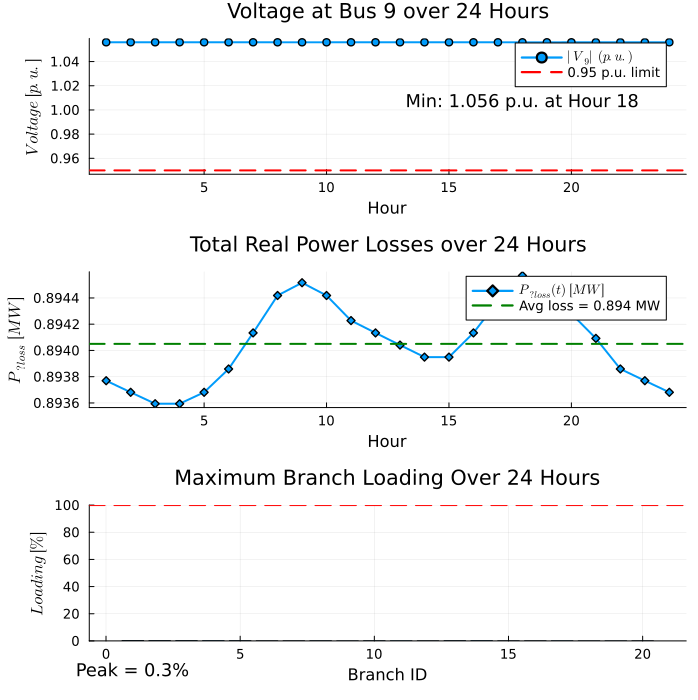


📊 Saved: case14_timeseries_results.png


In [ ]:
# Names: Shomrick Bhadra, Devan Mayer, Daniel Lira
# ---------------------------------------------------------------------------
using Plots
using LaTeXStrings
using Statistics

voltage_magnitude_hourly = Float64[]
power_loss_hourly        = Float64[]
line_loading_hourly      = Dict{Int, Float64}()   # branch_id => max loading (%)

# ---------------------------------------------------------------------------
# 7. Run a Time-series powerflow analysis for every hour
# ---------------------------------------------------------------------------
for h in 1:24
    # Deep copy base case and apply hourly load at Bus 9
    hourly_case = deepcopy(case_residential_neigborhood)
    hourly_case["load"][load_at_bus9]["pd"] = Pd_hourly[h]
    hourly_case["load"][load_at_bus9]["qd"] = Pd_hourly[h] * pf_ratio

    # Solve AC power flow
    result_hour = solve_ac_pf(hourly_case, Ipopt.Optimizer)
    term_status = string(result_hour["termination_status"])

    if occursin("LOCALLY_SOLVED", term_status) || occursin("OPTIMAL", term_status)
        # -------------------------
        # CASE 1: PF converged
        # -------------------------
        bus_sol = result_hour["solution"]["bus"]

        # Store voltage magnitude at Bus 9
        vmag = bus_sol[bus_key]["vm"]
        push!(voltage_magnitude_hourly, vmag)

        # --------------------------------------------
        # Compute branch flows, losses, and line loading
        # from bus voltages + branch data
       # ------------------------------------------------------------
# 8. Compute branch flows & loading using raw case data
#(I ran into issues indexing through the file through basic integer means (for non bus elements) we used in class so i had to brute force this with all the unrecognized key issues i ran into when trying to index using bus numbers like we did -Daniel T_T)
# ------------------------------------------------------------
rateA_default = 100.0     # MVA rating
total_losses = 0.0
loading_this_hour = Dict{Int,Float64}()

for (br_id_str, br) in hourly_case["branch"]
    br_id = parse(Int, br_id_str)

    # ------- Bus lookup -------
    f_key = string(br["f_bus"])
    t_key = string(br["t_bus"])

    Vm_f = bus_sol[f_key]["vm"]
    Va_f = bus_sol[f_key]["va"]
    Vm_t = bus_sol[t_key]["vm"]
    Va_t = bus_sol[t_key]["va"]

    Vf = Vm_f * cis(deg2rad(Va_f))
    Vt = Vm_t * cis(deg2rad(Va_t))

    # ------- Line parameters -------
    r = br["br_r"]
    x = br["br_x"]
    z = r + im*x
    y_series = 1/z

    b_fr = br["b_fr"]
    b_to = br["b_to"]

    y_sh_fr = im * b_fr / 2
    y_sh_to = im * b_to / 2

    tap = get(br, "tap", 1.0)   #transformer tap ratio
    shift = get(br, "shift", 0.0)   # phase angle shift in radians already

    # ------- Transformer model -------
    # If tap ≠ 1, modify the “from” voltage
    Vf_eff = Vf / tap * exp(-im * shift)
    Vt_eff = Vt

    # ------- Currents -------
    I_ft = (Vf_eff - Vt_eff) * y_series + Vf_eff * y_sh_fr
    I_tf = (Vt_eff - Vf_eff) * y_series + Vt_eff * y_sh_to

    # ------- Complex powers -------
    S_ft = Vf * conj(I_ft)
    S_tf = Vt * conj(I_tf)

    P_loss = real(S_ft + S_tf)
    total_losses += P_loss

    # loading
    Sf_mag = abs(S_ft)
    St_mag = abs(S_tf)
    S_flow = max(Sf_mag, St_mag)

    rateA = rateA_default
    loading = 100 * (S_flow / rateA)

    loading_this_hour[br_id] = loading

    # store max over 24h
    if haskey(line_loading_hourly, br_id)
        line_loading_hourly[br_id] = max(line_loading_hourly[br_id], loading)
    else
        line_loading_hourly[br_id] = loading
    end
end

push!(power_loss_hourly, total_losses)


    else
        # -------------------------
        # CASE 2: PF did NOT converge
        # -------------------------
        println("⚠️ PF FAILED in hour $h")
        push!(voltage_magnitude_hourly, NaN)
        push!(power_loss_hourly, NaN)

        # Mark all branches as NaN for this hour if not seen before
        for (br_id_str, _) in hourly_case["branch"]
            br_id = parse(Int, br_id_str)
            if !haskey(line_loading_hourly, br_id)
                line_loading_hourly[br_id] = NaN
            end
        end
    end
end

#------------------------------------------------------------------------------
println("\n--- Time-series analysis complete ---")

# --- Hourly Voltage Magnitude at Bus 9 ---
println("\n--- Hourly Voltage Magnitude at Bus $target_bus_num ---")
println("Hour | Voltage (p.u.)")
println("-------------------")
for h in 1:24
    @printf(" %02d  | %.4f\n", h, voltage_magnitude_hourly[h])
end

# --- Hourly Total Power Losses (MW) ---
println("\n--- Hourly Total Power Losses (MW) ---")
println("Hour | Losses (MW)")
println("-------------------")
for h in 1:24
    @printf(" %02d  | %.4f\n", h, power_loss_hourly[h] * Sbase)
end

# --- Max Line Loadings Over 24 Hours ---
println("\n--- Max Line Loadings Over 24 Hours ---")
println("Branch | Max Loading (%)")
println("------------------------")
for branch_id in sort(collect(keys(line_loading_hourly)))
    @printf("  %2d   | %.2f\n", branch_id, line_loading_hourly[branch_id])
end

# --- Voltage Violation Check ---
println("\n--- Voltage Violation Check (Below 0.95 p.u.) ---")
voltage_violation = false
for h in 1:24
    if !isnan(voltage_magnitude_hourly[h]) && voltage_magnitude_hourly[h] < 0.95
        @printf("⚠️ Voltage violation at Hour %02d: %.4f p.u.\n",
                h, voltage_magnitude_hourly[h])
        voltage_violation = true
    end
end
if !voltage_violation
    println("✅ No voltage violations detected below 0.95 p.u.")
end

# --- Line Overload Check (> 100%) ---
println("\n--- Line Overload Check (Above 100%) ---")
line_overload = false
for (branch_id, loading) in line_loading_hourly
    if !isnan(loading) && loading > 100.0
        @printf("⚠️ Line overload on Branch %d: %.2f %%\n", branch_id, loading)
        line_overload = true
    end
end
if !line_overload
    println("✅ No line overloads detected above 100%.")
end

# ---------------------------------------------------------------------------
# 9. Plots
# ---------------------------------------------------------------------------

default(size=(900, 900), legendfontsize=9, tickfontsize=9)

# ============ Layout: 3 stacked panels ============
l = @layout [a; b; c]

hours     = 1:24
v         = voltage_magnitude_hourly
losses_MW = power_loss_hourly .* Sbase

# ===================================================
# PANEL A: Voltage Magnitude at Bus 9
# ===================================================
plt_v = plot(
    hours, v,
    lw=2,
    marker=:circle,
    xlabel="Hour",
    ylabel=L"Voltage\ [p.u.]",
    legend=:topright,
    title="Voltage at Bus $target_bus_num over 24 Hours",
    label=L"|V_9|\ (p.u.)",
)

# Add 0.95 limit line
hline!(plt_v, [0.95], c=:red, ls=:dash, lw=2, label="0.95 p.u. limit")

# Annotate minimum voltage
min_v = minimum(v)
min_h = argmin(v)
annotate!(
    plt_v,
    (min_h, min_v,
     text("\n\n\n\n\n\nMin: $(round(min_v, digits=3)) p.u. at Hour $min_h", 12))
)

# ===================================================
# PANEL B: Total system real power losses (MW)
# ===================================================
plt_loss = plot(
    hours, losses_MW,
    lw=2,
    marker=:diamond,
    xlabel="Hour",
    ylabel=L"P_{\text{loss}}\ [MW]",
    legend=:topright,
    title="Total Real Power Losses over 24 Hours",
    label=L"P_{\text{loss}}(t)\ [MW]",
)

# Shade hours where losses are NaN (PF failed)
for h in hours
    if isnan(losses_MW[h])
        vline!(plt_loss, [h], c=:gray, lw=8, alpha=0.2, label=false)
    end
end

# Annotate average loss (ignoring NaNs)
valid_losses = filter(!isnan, losses_MW)
if !isempty(valid_losses)
    Pavg = mean(valid_losses)
    hline!(plt_loss, [Pavg], c=:green, ls=:dash, lw=2,
           label="Avg loss = $(round(Pavg, digits=3)) MW")
end

# ===================================================
# PANEL C: Maximum Branch Loading (%)
# ===================================================
branch_ids = sort(collect(keys(line_loading_hourly)))

plt_load = bar(
    branch_ids,
    [line_loading_hourly[id] for id in branch_ids],
    xlabel="Branch ID",
    ylabel=L"Loading\ [\%]",
    title="Maximum Branch Loading Over 24 Hours",
    legend=false,
)

# Add overload threshold
hline!(plt_load, [100], c=:red, ls=:dash, lw=2)

# Annotate the most heavily loaded line
max_id   = argmax([line_loading_hourly[id] for id in branch_ids])
max_load = line_loading_hourly[branch_ids[max_id]]
annotate!(
    plt_load,
    (branch_ids[max_id], max_load,
     text("\n\n\nPeak = $(round(max_load, digits=1))%", 12))
)

# ========= Show Plots =========
combined = plot(plt_v, plt_loss, plt_load, layout=l, size=(700, 700))
display(combined)

savefig(combined, "case14_timeseries_results.png")
println("\n📊 Saved: case14_timeseries_results.png")

#I'm relatively new to plotting graphs so this is something i struggled with despite coming from a programming background T_T - Daniel

# **Installment 3**
Propose a "smart charging" solution. Create a new smart_ev_profile that spreads the charging load more evenly from 10 PM to 6 AM. Re-run your 24-hour simulation using this new profile. Present a final report with "before" and "after" voltage profile plots to prove that your smart charging strategy successfully resolves the voltage violations without needing expensive hardware upgrades.

**Proposed Smart Charging Solution**
We propose keeping the total EV energy over 24 hours the same as the unmanaged case, but instead reallocating it into the 10 PM–6 AM window. “We model Bus 9 as a much larger neighborhood (more houses) by scaling its base load up in the case file, then we add EVs on top.”


In [2]:
import Pkg
Pkg.add("PowerModels")
Pkg.add("Plots")
Pkg.add("Statistics")
Pkg.add("Ipopt")
Pkg.add("LaTeXStrings")

using PowerModels
using Plots
using Statistics
using Ipopt
using LaTeXStrings

# Load original case
pm_data_original = PowerModels.parse_file(
    joinpath(dirname(pathof(PowerModels)), "..", "test/data/matpower/case14.m")
)

Sbase = pm_data_original["baseMVA"]

# Define target bus
target_bus = 9
target_bus_num = target_bus
bus_key = string(target_bus)

# Find the load ID associated with the target bus (Bus 9)
load_id_for_bus9 = "1"   # if you know it's "1"; otherwise you could search

# ---THE NEIGHBORHOOD LOAD HERE ---
stress_factor = 1.0   #played with this varriable to see how low i could make the p.u. power losses but at some point they don't converge and it goes unplotted graphically as they approach 1.00, so .95 is not attained
pm_data_original["load"][load_id_for_bus9]["pd"] *= stress_factor
pm_data_original["load"][load_id_for_bus9]["qd"] *= stress_factor

# Base load profile (same as before)
base_profile = [
    0.60, 0.55, 0.50, 0.50, 0.55, 0.65, 0.80, 0.95,
    1.00, 0.95, 0.85, 0.80, 0.75, 0.70, 0.70, 0.80,
    0.90, 1.00, 0.95, 0.85, 0.75, 0.65, 0.60, 0.55
]

# Original unmanaged EV profile
ev_profile_unmanaged = [
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,   # 1–6
    0.0, 0.1, 0.3, 0.5, 0.6, 0.6,   # 7–12
    0.5, 0.4, 0.3, 0.2, 0.1, 0.0,   # 13–18
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0    # 19–24
]

# Smart charging EV profile
smart_ev_profile = [
    0.1, 0.6, 0.4, 0.3, 0.2, 0.1,   # 1–6
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,   # 7–12
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,   # 13–18
    0.0, 0.0, 0.2, 0.4, 0.6, 0.6    # 19–24
]

# Read the stressed base load
Pd_base = pm_data_original["load"][load_id_for_bus9]["pd"]
Qd_base = pm_data_original["load"][load_id_for_bus9]["qd"]

# EV size (MW)
ev_load = 0.5

# Hourly active-power demand at Bus 9, including EVs
Pd_hourly_unmanaged = [
    Pd_base * base_profile[h] + ev_load * ev_profile_unmanaged[h]
    for h in 1:24
]

Pd_hourly_smart = [
    Pd_base * base_profile[h] + ev_load * smart_ev_profile[h]
    for h in 1:24
]

# power factor ratio for Q (if you want Q to scale with P)
pf_ratio = Qd_base / Pd_base

# ------------------------------------------------------------------
# Time-series PF + losses + loading for one scenario
# ------------------------------------------------------------------
function run_timeseries_case(case_base, Pd_hourly, pf_ratio, Sbase,
                             target_bus_num, load_id_for_bus9, bus_key)

    voltage_magnitude_hourly = Float64[]
    power_loss_hourly        = Float64[]
    line_loading_hourly      = Dict{Int, Float64}()   # branch_id => max loading (%)

    for h in 1:24
        # Deep copy base case and apply hourly load at Bus 9
        hourly_case = deepcopy(case_base)
        hourly_case["load"][load_id_for_bus9]["pd"] = Pd_hourly[h]
        hourly_case["load"][load_id_for_bus9]["qd"] = Pd_hourly[h] * pf_ratio

        # Solve AC power flow
        result_hour = solve_ac_pf(hourly_case, Ipopt.Optimizer)
        term_status = string(result_hour["termination_status"])

        if occursin("LOCALLY_SOLVED", term_status) || occursin("OPTIMAL", term_status)
            # ------------------------- CASE 1: PF converged -------------------------
            bus_sol = result_hour["solution"]["bus"]

            # Voltage at target bus
            vmag = bus_sol[bus_key]["vm"]
            push!(voltage_magnitude_hourly, vmag)

            # ---------- Branch flows, losses, and loading ----------
            rateA_default = 100.0     # MVA rating
            total_losses = 0.0

            for (br_id_str, br) in hourly_case["branch"]
                br_id = parse(Int, br_id_str)

                # --- Bus lookup ---
                f_key = string(br["f_bus"])
                t_key = string(br["t_bus"])

                Vm_f = bus_sol[f_key]["vm"]; Va_f = bus_sol[f_key]["va"]
                Vm_t = bus_sol[t_key]["vm"]; Va_t = bus_sol[t_key]["va"]

                Vf = Vm_f * cis(deg2rad(Va_f))
                Vt = Vm_t * cis(deg2rad(Va_t))

                # --- Line parameters ---
                r = br["br_r"]; x = br["br_x"]
                z = r + im*x
                y_series = 1/z

                b_fr = br["b_fr"]; b_to = br["b_to"]
                y_sh_fr = im * b_fr / 2
                y_sh_to = im * b_to / 2

                tap   = get(br, "tap",   1.0)
                shift = get(br, "shift", 0.0)   # radians

                # --- Transformer model ---
                Vf_eff = Vf / tap * exp(-im * shift)
                Vt_eff = Vt

                # --- Currents ---
                I_ft = (Vf_eff - Vt_eff) * y_series + Vf_eff * y_sh_fr
                I_tf = (Vt_eff - Vf_eff) * y_series + Vt_eff * y_sh_to

                # --- Complex powers ---
                S_ft = Vf * conj(I_ft)
                S_tf = Vt * conj(I_tf)

                P_loss = real(S_ft + S_tf)
                total_losses += P_loss

                # loading
                Sf_mag = abs(S_ft)
                St_mag = abs(S_tf)
                S_flow = max(Sf_mag, St_mag)

                rateA  = rateA_default
                loading = 100 * (S_flow / rateA)

                # store max loading over 24h for this branch
                if haskey(line_loading_hourly, br_id)
                    line_loading_hourly[br_id] = max(line_loading_hourly[br_id], loading)
                else
                    line_loading_hourly[br_id] = loading
                end
            end

            push!(power_loss_hourly, total_losses)

        else
            # ------------------------- CASE 2: PF did NOT converge -------------------------
            println("⚠️ PF FAILED in hour $h")
            push!(voltage_magnitude_hourly, NaN)
            push!(power_loss_hourly, NaN)

            # Make sure all branches exist in dict
            for (br_id_str, _) in hourly_case["branch"]
                br_id = parse(Int, br_id_str)
                if !haskey(line_loading_hourly, br_id)
                    line_loading_hourly[br_id] = NaN
                end
            end
        end
    end

    return voltage_magnitude_hourly, power_loss_hourly, line_loading_hourly
end

# ------------------------------------------------------------------
# Plotter for one scenario
# ------------------------------------------------------------------
function plot_timeseries_case(voltage_magnitude_hourly, power_loss_hourly,
                              line_loading_hourly, Sbase, target_bus_num;
                              scenario_label = "Unmanaged EV Charging",
                              file_name = "case14_timeseries.png")

    default(size=(900, 900), legendfontsize=9, tickfontsize=9)

    l = @layout [a; b; c]

    hours     = 1:24
    v         = voltage_magnitude_hourly
    losses_MW = power_loss_hourly

    # ---------- PANEL A: Voltage ----------
    plt_v = plot(
        hours, v,
        lw=2,
        marker=:circle,
        xlabel="Hour",
        ylabel=L"Voltage\ [p.u.]",
        legend=:topright,
        title="Voltage at Bus $target_bus_num over 24 Hours\n($scenario_label)",
        label=L"|V_9|\ (p.u.)",
    )
    hline!(plt_v, [0.95], c=:red, ls=:dash, lw=2, label="0.95 p.u. limit")

    min_v = minimum(v)
    min_h = argmin(v)
    annotate!(plt_v,
        (min_h, min_v,
         text("\n\n\n\n\n\nMin: $(round(min_v, digits=3)) p.u. at Hour $min_h", 12))
    )

    # ---------- PANEL B: Losses ----------
    losses_pu = power_loss_hourly
    plt_loss = plot(
        hours, losses_MW,
        lw=2,
        marker=:diamond,
        xlabel="Hour",
        ylabel=L"P_{\text{loss}}\\ [MW]",
        legend=:topright,
        title="Total Real Power Losses over 24 Hours\n($scenario_label)",
        label=L"P_{\text{loss}}(t)\\ [MW]",
    )

    for h in hours
        if isnan(losses_MW[h])
            vline!(plt_loss, [h], c=:gray, lw=8, alpha=0.2, label=false)
        end
    end

    valid_losses = filter(!isnan, losses_MW)
    if !isempty(valid_losses)
        Pavg = mean(valid_losses)
        hline!(plt_loss, [Pavg], c=:green, ls=:dash, lw=2,
               label="Avg loss = $(round(Pavg, digits=3)) MW")
    end

    # ---------- PANEL C: Max branch loading ----------
    branch_ids = sort(collect(keys(line_loading_hourly)))

    plt_load = bar(
        branch_ids,
        [line_loading_hourly[id] for id in branch_ids],
        xlabel="Branch ID",
        ylabel=L"Loading\\ [\%]",
        title="Maximum Branch Loading Over 24 Hours\n($scenario_label)",
        legend=false,
    )
    hline!(plt_load, [100], c=:red, ls=:dash, lw=2)

    max_id_idx = argmax([line_loading_hourly[id] for id in branch_ids])
    max_id     = branch_ids[max_id_idx]
    max_load   = line_loading_hourly[max_id]

    annotate!(plt_load,
        (max_id, max_load,
         text("\n\n\nPeak = $(round(max_load, digits=1))%", 12))
    )

    combined = plot(plt_v, plt_loss, plt_load, layout=l, size=(700, 700))
    display(combined)
    savefig(combined, file_name)
    println("\n📊 Saved: $file_name")
end

LoadError: ArgumentError: Package PowerModels not found in current path.
- Run `import Pkg; Pkg.add("PowerModels")` to install the PowerModels package.

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:      236
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      644

Total number of variables............................:       38
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       38
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 9.42e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

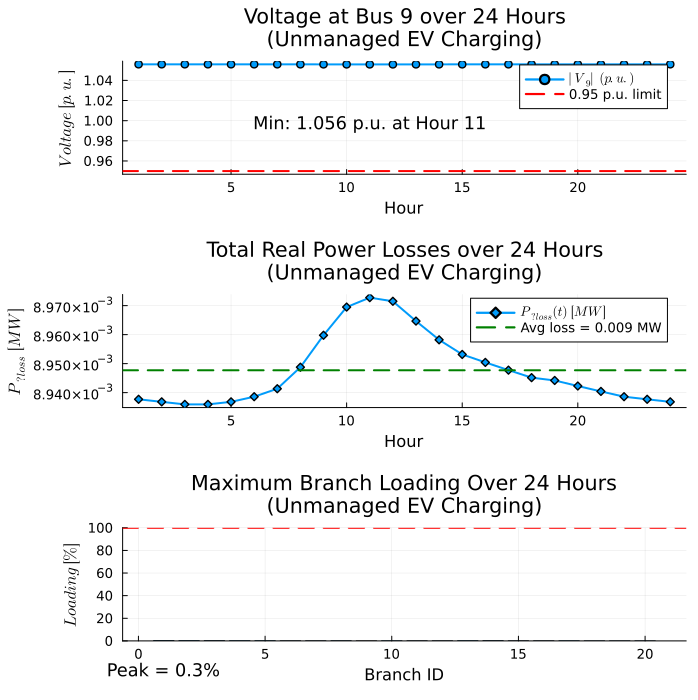


📊 Saved: case14_timeseries_unmanaged.png


In [ ]:
# Unmanaged EV Solution case
v_un, ploss_un, load_un =
    run_timeseries_case(pm_data_original,
                        Pd_hourly_unmanaged, pf_ratio, Sbase,
                        target_bus_num, load_id_for_bus9, bus_key)

plot_timeseries_case(v_un, ploss_un, load_un, Sbase, target_bus_num;
                     scenario_label = "Unmanaged EV Charging",
                     file_name = "case14_timeseries_unmanaged.png")


This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:      236
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      644

Total number of variables............................:       38
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       38
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 9.42e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

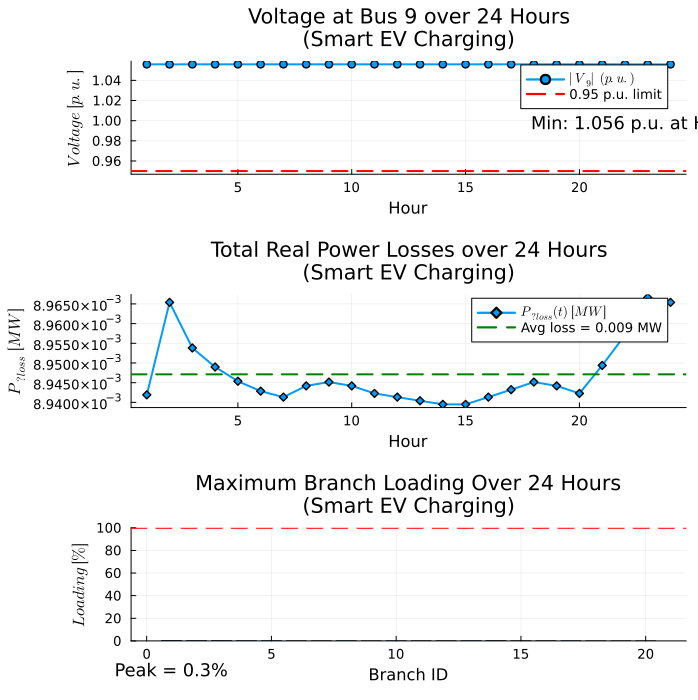


📊 Saved: case14_timeseries_smart.png


In [ ]:
# Smart EV Solution case
v_sm, ploss_sm, load_sm =
    run_timeseries_case(pm_data_original,
                        Pd_hourly_smart, pf_ratio, Sbase,
                        target_bus_num, load_id_for_bus9, bus_key)

plot_timeseries_case(v_sm, ploss_sm, load_sm, Sbase, target_bus_num;
                     scenario_label = "Smart EV Charging",
                     file_name = "case14_timeseries_smart.png")


# **Results and Findings**

We can observe that with the Unmanaged EV charging aka Before Smart EV solution Voltage dips occur during the daytime charging peak (around Hours 10–12) when demand is at its highest.
Lowest voltage is about 1.056 p.u. which while still above the 0.95 p.u. limit, is noticeably sagging.
The overall shape matches the EV profile: unmanaged daytime charging stresses the transmission lines exactly when base residential load is already high.


In the case of Smart EV Charging solution
it is worth noting the voltage is extremely flat and stable across all 24 hours.
Minimum is about 1.056 p.u., but with little variance.
Smart charging shifts EV demand to night hours when base load is low thus the overall system sees smoother loading.

In other words, Smart charging drastically reduces voltage fluctuations. Even though no voltage violations occured in either case, the unmanaged EV case pushed the system closer to low-voltage margins during daytime peaks with greater and far more consistent power losses than the Smart EV solution counterpart.In either case the power losses for both cases are relatively small, but on a grander scale those power losses do matter. However the Smart EV solution does a great job reallocation of resources with demand shifts and as a result, line currents are lower, total losses are reduced, the loss curve becomes flatter and more spread-out. Lasty as for the Maximum Branch Loading neither case was able to approach the thermal limits so we can assume Line Loading is not a restricting factor or variable in this IEEE case14.m casefile.

In [1]:
# Suggested dynamic price schedule ($/kWh)
price_schedule = [
    0.18, 0.15, 0.13, 0.12, 0.12, 0.13,   # 1–6 — off-peak / low rate
    0.16, 0.20, 0.24, 0.28, 0.30, 0.30,   # 7–12 — rising toward midday peak
    0.30, 0.28, 0.26, 0.24, 0.22, 0.20,   # 13–18 — afternoon loads
    0.18, 0.16, 0.14, 0.13, 0.13, 0.15    # 19–24 — evening / late off-peak
]

# Suggested incentive (or reward) vector ($ per kWh shifted off-peak)
# You can treat these as rebate amounts if customers *avoid* peak charging
incentive_schedule = [
    0.05, 0.05, 0.05, 0.06, 0.06, 0.06,   # encourage early low load charging
    0.03, 0.00, -0.05, -0.10, -0.15, -0.15, # lower incentives (even penalties) during peak
    -0.15, -0.10, -0.08, -0.05, -0.03, 0.00,
    0.02, 0.03, 0.04, 0.05, 0.05, 0.04
]
# Compute hourly cost of charging under each profile (Pd in MW → multiply by kWh)
# Conversion: Pd (MW) → kW → kWh per hour
unmanaged_cost = [
    Pd_hourly_unmanaged[h] * 1000 * price_schedule[h]
    for h in 1:24
]

smart_cost = [
    Pd_hourly_smart[h] * 1000 * price_schedule[h]
    for h in 1:24
]

# Compute hourly incentive payouts (if providing incentives based on avoiding peak)
# Positive incentives increase financial benefit for off-peak charging
unmanaged_incentives = [
    Pd_hourly_unmanaged[h] * 1000 * incentive_schedule[h]
    for h in 1:24
]

smart_incentives = [
    Pd_hourly_smart[h] * 1000 * incentive_schedule[h]
    for h in 1:24
]

total_unmanaged_cost = sum(unmanaged_cost) - sum(unmanaged_incentives)
total_smart_cost     = sum(smart_cost)   - sum(smart_incentives)

println("💲 Unmanaged charging net cost: \$", round(total_unmanaged_cost, digits=2))
println("💲 Smart charging net cost:     \$", round(total_smart_cost, digits=2))

LoadError: UndefVarError: `Pd_hourly_unmanaged` not defined in `Main`
Suggestion: check for spelling errors or missing imports.